# Compare Inversion Calls Across Treatments
What would be interesting to see is the inversion-calling performance in linked reads across inversion sizes and depths. Since we already created the assessment tables from the individual size-class data exploration, we can read those in without having to reprocess those data.

In [46]:
library(ggplot2)
library(dplyr)
library(stringr)
library(tidyr)
library(ggh4x)
library(ggpubr)
options(warn = -1)

Read in the LEVIATHAN linked-read variant assessments. Remove the `inversion` and `id` columns. We will add the leviathan candidates as their own `technology` and do the same with the pooled data.

In [2]:
.lev <- read.csv("assess_sv_leviathan/visor/linkedread.sv.assessment", header = T) %>%
    select(-inversion, -id, -candidate)
.lev$technology[.lev$sample == 11] <- "linkedread (pooled)"
.lev$zygosity[.lev$sample == 11] <- "homozygous"

# rm pooled from the candidates
.lev_cand <- select(.lev, -assessment) %>% rename("assessment" = assess_cand) %>% filter(sample < 11)

# rename the false negative (filtered) to "true positive" to posit an ideal world where candidates were detected
.lev_cand$assessment[grepl("filtered", .lev_cand$assessment)] <- "true positive"
.lev_cand$assessment[grepl("undetected", .lev_cand$assessment)] <- "false negative"
.lev_cand$technology <- "linkedread (candidates)"

leviathan <- rbind(select(.lev, -assess_cand), .lev_cand)

table(leviathan$technology)
table(leviathan$assessment)
head(leviathan)


             linkedread linkedread (candidates)     linkedread (pooled) 
                   2400                    2400                     240 


false negative  true negative  true positive 
          1236           1300           2504 

,contig,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method
,<chr>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,2L,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
2,2L,2.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan
3,2L,5.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
4,2L,10.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
5,2L,20.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan
6,2L,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan


In [3]:
naibr <- read.csv("assess_sv_naibr/visor/linkedread.sv.assessment", header = T) %>%
    select(-inversion, -id)
table(naibr$assessment)
head(naibr)


false negative  true negative  true positive 
          1323            650            667 

,contig,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method
,<chr>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,2L,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
2,2L,2.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
3,2L,5.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
4,2L,10.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
5,2L,20.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
6,2L,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr


For the short reads, we can rename the values in the `technology` column as `shortread`

In [4]:
delly <- read.csv("assess_sv_delly/linkedread.sv.assessment", header = T) %>%
    mutate(technology = "shortread") %>%
    select(-inversion, -id)

table(delly$assessment)
head(delly)


false negative  true negative  true positive 
           407            650           1343 

,contig,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method
,<chr>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,2L,0.5,1,small,TRUE,homozygous,3193196,3214221,true positive,shortread,delly2
2,2L,2.0,1,small,TRUE,homozygous,3193196,3214221,true positive,shortread,delly2
3,2L,5.0,1,small,TRUE,homozygous,3193196,3214221,true positive,shortread,delly2
4,2L,10.0,1,small,TRUE,homozygous,3193196,3214221,true positive,shortread,delly2
5,2L,20.0,1,small,TRUE,homozygous,3193196,3214221,true positive,shortread,delly2
6,2L,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,shortread,delly2


Read in the long-read variant assessment. Rename the columns because I clearly wasn't consistent doing this over and over again.

In [5]:
longread <- read.csv("longread_workflow/longread.sv.assessment", header = T) %>%
    rename("simulated" = present, "technology" = platform) %>%
    mutate(
        method = "sniffles",
        sample = as.integer(gsub("sample_", "", sample))
    )

table(longread$assessment)
head(longread)


false negative  true negative  true positive 
          1194           1950           4056 

,sample,contig,position_start,position_end,size,simulated,zygosity,assessment,depth,technology,method
,<int>,<chr>,<int>,<int>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,1,2L,11529165,15060030,large,TRUE,homozygous,false negative,0.5,pacbio,sniffles
2,1,2L,11529165,15060030,large,TRUE,homozygous,true positive,0.5,ontlong,sniffles
3,1,2L,11529165,15060030,large,TRUE,homozygous,false negative,0.5,ontshort,sniffles
4,1,2L,11529165,15060030,large,TRUE,homozygous,true positive,2.0,pacbio,sniffles
5,1,2L,11529165,15060030,large,TRUE,homozygous,true positive,2.0,ontlong,sniffles
6,1,2L,11529165,15060030,large,TRUE,homozygous,true positive,2.0,ontshort,sniffles


In [6]:
assess <- rbind(leviathan, naibr, delly, longread) %>%
    mutate(
        size = factor(size, ordered = T, levels = c("small","medium","large","xl")),
        technology = factor(technology, ordered = T, levels = c("linkedread", "linkedread (pooled)", "linkedread (candidates)", "shortread", "ontshort", "ontlong", "pacbio")),
        zygosity = as.factor(zygosity),
        assessment = as.factor(assessment),
        method = as.factor(method),
        frequency = case_when(
            contig == "2L" ~ "common",
            contig == "2R" ~ "common",
            contig == "3R" ~ "common",
            contig == "3L" ~ "rare"
        )
    )

head(assess)

,contig,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method,frequency
,<chr>,<dbl>,<int>,<ord>,<lgl>,<fct>,<int>,<int>,<fct>,<ord>,<fct>,<chr>
1,2L,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan,common
2,2L,2.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan,common
3,2L,5.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan,common
4,2L,10.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan,common
5,2L,20.0,1,small,TRUE,homozygous,3193196,3214221,true positive,linkedread,leviathan,common
6,2L,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,leviathan,common


Let's also make some of the columns factors.

## Sample-level Calling
### Prepare the Data
It would probably make sense to collapse these data somewhat to show a representation of true positives vs false negatives (as a ratio) across depths (x axis) and faceted for hom/het. We will also remove inversions that weren't simulated for a sample b/c we aren't interested in true negatives (since there were no false positives). Let's also remove `naibr` (for now).

In [7]:
.assess <- as.vector(outer(c("true", "false"), c("positive", "negative"), paste))
samples <- assess[assess$method != "naibr",] %>%
    group_by(size, depth, zygosity, assessment, technology) %>%
    summarize(count = n()) %>% ungroup() %>%
    complete(size, depth, zygosity, technology, assessment = .assess[c(-2)], fill = list(count = 0))

head(samples)

samples_freq <- assess[assess$method != "naibr",] %>%
    group_by(size, depth, frequency, assessment, technology) %>%
    summarize(count = n()) %>% ungroup() %>%
    complete(size, depth, frequency, technology, assessment = .assess[c(-2)], fill = list(count = 0))

head(samples_freq)


`summarise()` has grouped output by 'size', 'depth', 'zygosity', 'assessment'.
You can override using the `.groups` argument.


size,depth,zygosity,technology,assessment,count
<ord>,<dbl>,<fct>,<ord>,<chr>,<int>
small,0.5,heterozygous,linkedread,false negative,72
small,0.5,heterozygous,linkedread,true negative,0
small,0.5,heterozygous,linkedread,true positive,2
small,0.5,heterozygous,linkedread (pooled),false negative,0
small,0.5,heterozygous,linkedread (pooled),true negative,0
small,0.5,heterozygous,linkedread (pooled),true positive,0


`summarise()` has grouped output by 'size', 'depth', 'frequency', 'assessment'.
You can override using the `.groups` argument.


size,depth,frequency,technology,assessment,count
<ord>,<dbl>,<chr>,<ord>,<chr>,<int>
small,0.5,common,linkedread,false negative,130
small,0.5,common,linkedread,true negative,17
small,0.5,common,linkedread,true positive,3
small,0.5,common,linkedread (pooled),false negative,6
small,0.5,common,linkedread (pooled),true negative,0
small,0.5,common,linkedread (pooled),true positive,9


In [8]:
# this function automates reading in everything all at once returns an empty table if there are no false positives
read.fp <- function(dir){
    val <- Reduce(rbind,
        Map(
            function(x){ read.table(x, header = T) },
            list.files(dir, pattern = "false_positives*", full.names = T)
        )
    )
    if (is.null(val)){
        return(
            data.frame(
                contig = character(),
                position_start = integer(),
                position_end = integer(),
                sample = integer(),
                depth = numeric(),
                size = character(),
                method = character()
            )
        )
    } else {
        return(val)
    }
}

In [9]:
false_positives <- Reduce(
    rbind,
    Map(read.fp, c("assess_sv_delly", "assess_sv_leviathan/visor", "longread_workflow"))
) %>% rename("technology" = method) %>%
    mutate(
        assessment = "false positive",
        technology = gsub("delly", "shortread", technology),
        zygosity = case_when(
            contig == "2L" ~ "homozygous",
            contig == "2R" ~ "heterozygous",
            contig == "3R" ~ "homozygous",
            contig == "3L" ~ "heterozygous"
        )
)

head(false_positives)

samples_consolidated <- group_by(samples, size, depth, technology, assessment, zygosity) %>%
    summarise(count = sum(count)) %>% ungroup()
head(samples_consolidated)


samples_consolidated_noz <- group_by(samples, size, depth, technology, assessment) %>%
    summarise(count = sum(count)) %>% ungroup()
head(samples_consolidated_noz)

samples_freq <- group_by(samples_freq, size, depth, technology, frequency, assessment) %>%
    summarise(count = sum(count)) %>% ungroup()
head(samples_freq)

,contig,position_start,position_end,sample,depth,size,technology,assessment,zygosity
,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,2L,6436108,6636405,4,0.5,medium,shortread,false positive,homozygous
2,3L,1700609,1761574,9,0.5,medium,shortread,false positive,heterozygous
3,3L,1700628,1761915,1,0.5,medium,shortread,false positive,heterozygous
4,3L,1700628,1761915,6,0.5,medium,shortread,false positive,heterozygous
5,2L,6436142,6636405,1,2.0,medium,shortread,false positive,homozygous
6,2L,6436142,6636405,2,2.0,medium,shortread,false positive,homozygous


`summarise()` has grouped output by 'size', 'depth', 'technology',
'assessment'. You can override using the `.groups` argument.


size,depth,technology,assessment,zygosity,count
<ord>,<dbl>,<ord>,<chr>,<fct>,<int>
small,0.5,linkedread,false negative,heterozygous,72
small,0.5,linkedread,false negative,homozygous,67
small,0.5,linkedread,true negative,heterozygous,0
small,0.5,linkedread,true negative,homozygous,57
small,0.5,linkedread,true positive,heterozygous,2
small,0.5,linkedread,true positive,homozygous,2


`summarise()` has grouped output by 'size', 'depth', 'technology'. You can
override using the `.groups` argument.


size,depth,technology,assessment,count
<ord>,<dbl>,<ord>,<chr>,<int>
small,0.5,linkedread,false negative,139
small,0.5,linkedread,true negative,57
small,0.5,linkedread,true positive,4
small,0.5,linkedread (pooled),false negative,10
small,0.5,linkedread (pooled),true negative,0
small,0.5,linkedread (pooled),true positive,10


`summarise()` has grouped output by 'size', 'depth', 'technology', 'frequency'.
You can override using the `.groups` argument.


size,depth,technology,frequency,assessment,count
<ord>,<dbl>,<ord>,<chr>,<chr>,<int>
small,0.5,linkedread,common,false negative,130
small,0.5,linkedread,common,true negative,17
small,0.5,linkedread,common,true positive,3
small,0.5,linkedread,rare,false negative,9
small,0.5,linkedread,rare,true negative,40
small,0.5,linkedread,rare,true positive,1


In [10]:
metrics <- group_by(false_positives, size, depth, assessment, technology, zygosity) %>%
    summarize(count = n()) %>% ungroup() %>%
    rbind(samples_consolidated) %>%
    arrange(size, depth, technology, assessment) %>%
    #filter(technology != "linkedread (candidates)") %>%
    complete(size, depth, technology, zygosity, assessment = .assess, fill = list(count = 0)) %>%
    pivot_wider(names_from = assessment, values_from = count) %>%
    rename(FN = "false negative", FP = "false positive", TN = "true negative", TP = "true positive")

head(metrics)

`summarise()` has grouped output by 'size', 'depth', 'assessment',
'technology'. You can override using the `.groups` argument.


size,depth,technology,zygosity,FN,FP,TN,TP
<chr>,<dbl>,<chr>,<chr>,<int>,<int>,<int>,<int>
large,0.5,linkedread,heterozygous,30,0,0,0
large,0.5,linkedread,homozygous,28,0,21,1
large,0.5,linkedread (candidates),heterozygous,9,0,0,21
large,0.5,linkedread (candidates),homozygous,3,0,21,26
large,0.5,linkedread (pooled),heterozygous,0,0,0,0
large,0.5,linkedread (pooled),homozygous,2,0,0,6


In [11]:
metrics <- mutate(metrics,
    precision = TP / (TP + FP),
    recall = TP / (TP + FN),
    F1 = 2 * ((precision * recall) / (precision + recall)),
    size = factor(size, ordered = T, levels = c("small", "medium", "large", "xl")),
    Accuracy = (TP + TN) / (TP + TN + FN + FP),
    FPR = FP / (FP + TN),
)
metrics[is.na(metrics)] <- 0

head(metrics)

metrics_global <- group_by(metrics, technology, depth, zygosity) |>
    summarize(FN = sum(FN), FP = sum(FP), TN = sum(TN), TP = sum(TP)) %>%
    mutate(
        precision = TP / (TP + FP),
        recall = TP / (TP + FN),
        F1 = 2 * ((precision * recall) / (precision + recall)),
        Accuracy = (TP + TN) / (TP + TN + FN + FP),
        FPR = FP / (FP + TN)
    )
metrics_global[is.na(metrics_global)] <- 0
head(metrics_global)

metrics_summary <- group_by(metrics, depth, technology) %>%
    summarize(FN = sum(FN), FP = sum(FP), TN = sum(TN), TP = sum(TP)) %>%
    mutate(
        precision = TP / (TP + FP),
        recall = TP / (TP + FN),
        F1 = 2 * ((precision * recall) / (precision + recall)),
        Accuracy = (TP + TN) / (TP + TN + FN + FP),
        FPR = FP / (FP + TN)
    )

metrics_summary[is.na(metrics_summary)] <- 0
head(metrics_summary)

size,depth,technology,zygosity,FN,FP,TN,TP,precision,recall,F1,Accuracy,FPR
<ord>,<dbl>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
large,0.5,linkedread,heterozygous,30,0,0,0,0,0.00000000,0.00000000,0.00,0
large,0.5,linkedread,homozygous,28,0,21,1,1,0.03448276,0.06666667,0.44,0
large,0.5,linkedread (candidates),heterozygous,9,0,0,21,1,0.70000000,0.82352941,0.70,0
large,0.5,linkedread (candidates),homozygous,3,0,21,26,1,0.89655172,0.94545455,0.94,0
large,0.5,linkedread (pooled),heterozygous,0,0,0,0,0,0.00000000,0.00000000,0.00,0
large,0.5,linkedread (pooled),homozygous,2,0,0,6,1,0.75000000,0.85714286,0.75,0


`summarise()` has grouped output by 'technology', 'depth'. You can override
using the `.groups` argument.


technology,depth,zygosity,FN,FP,TN,TP,precision,recall,F1,Accuracy,FPR
<chr>,<dbl>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
linkedread,0.5,heterozygous,179,0,0,2,1,0.01104972,0.02185792,0.01104972,0
linkedread,0.5,homozygous,163,0,130,6,1,0.03550296,0.06857143,0.45484950,0
linkedread,2.0,heterozygous,152,0,0,29,1,0.16022099,0.27619048,0.16022099,0
linkedread,2.0,homozygous,103,0,130,66,1,0.39053254,0.56170213,0.65551839,0
linkedread,5.0,heterozygous,71,0,0,110,1,0.60773481,0.75601375,0.60773481,0
linkedread,5.0,homozygous,46,0,130,123,1,0.72781065,0.84246575,0.84615385,0


`summarise()` has grouped output by 'depth'. You can override using the
`.groups` argument.


depth,technology,FN,FP,TN,TP,precision,recall,F1,Accuracy,FPR
<dbl>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.5,linkedread,342,0,130,8,1,0.02285714,0.04469274,0.2875000,0
0.5,linkedread (candidates),110,0,130,240,1,0.68571429,0.81355932,0.7708333,0
0.5,linkedread (pooled),23,0,0,25,1,0.52083333,0.68493151,0.5208333,0
0.5,ontlong,295,0,130,55,1,0.15714286,0.27160494,0.3854167,0
0.5,ontshort,309,0,130,41,1,0.11714286,0.20971867,0.3562500,0
0.5,pacbio,309,0,130,41,1,0.11714286,0.20971867,0.3562500,0


In [12]:
write.table(metrics, file = "metrics.csv", quote = F, sep = ",", row.names = F)
write.table(metrics_global, file = "metrics.zyg.overall.csv", quote = F, sep = ",", row.names = F)
write.table(metrics_summary, file = "metrics.summary.csv", quote = F, sep = ",", row.names = F)

Let's also set a color palette for the technology comparisons using the [Arches theme](https://github.com/katiejolly/nationalparkcolors/tree/master) and the Redwoods theme for the depths.

In [13]:
tech_colors <- c(
    "linkedread" = "#a8cdec",
    "linkedread (candidates)" = "#4babce",
    "linkedread (pooled)" = "#6c7780",
    "ontlong" = "#682c37",
    "ontshort" = "#9b6981",
    "pacbio" = "#f6955e" ,
    "shortread" = "#7285c3ff"
)

size_colors <- c(
    "#c0c6cf",
    "#a2aab5",
    "#6e7684",
    "#54546c"
)

depth_colors <- c(
    "#c0c6cf",
    "#a2aab5",
    "#6e7684",
    "#54546c",
    "#30303dff"
)

depth_colors2 <- c(
    "#c0c6cf",
    "#aeb3bb",
    "#9097a1",
    "#6e7684",
    "#5b616b",
    "#54546c",
    "#434355",
    "#30303dff"
)

zygosity_colors <- c(
    "#85a98eff",
    "#7fa9b4ff"
)

freq_colors <- c(
    "rare" = "#8C85A9",
    "common" = "#4C4271"
)

technology_lines <- c(
    "linkedread" = "solid",
    "linkedread (pooled)" = "dotdash",
    "linkedread (candidates)" = "dashed",
    "shortread" = "solid", 
    "ontshort" = "solid",
    "ontlong" = "solid",
    "pacbio" = "solid"
)

technology_shapes <- c(
    "linkedread" = 17,
    "linkedread (pooled)" = 12,
    "linkedread (candidates)" = 14,
    "shortread" = 25, 
    "ontshort" = 19,
    "ontlong" = 15,
    "pacbio" = 18
)

technology_shapes2 <- c(
    "linkedread" = 17,
    "linkedread (pooled)" = 12,
    "linkedread (candidates)" = 14,
    "shortread" = 19, 
    "ontshort" = 19,
    "ontlong" = 19,
    "pacbio" = 19
)

### Visualization
We are now interested in seeing how these performed. There are several dimensions to consider here:
- depth
- inversion size
- zygotic state
- sequencing technology

#### Detection between technologies across inversion classes
We'll approach this a few different ways to try to reveal meaningful information. First let's compare how each of the technologies did within a given inversion size class.

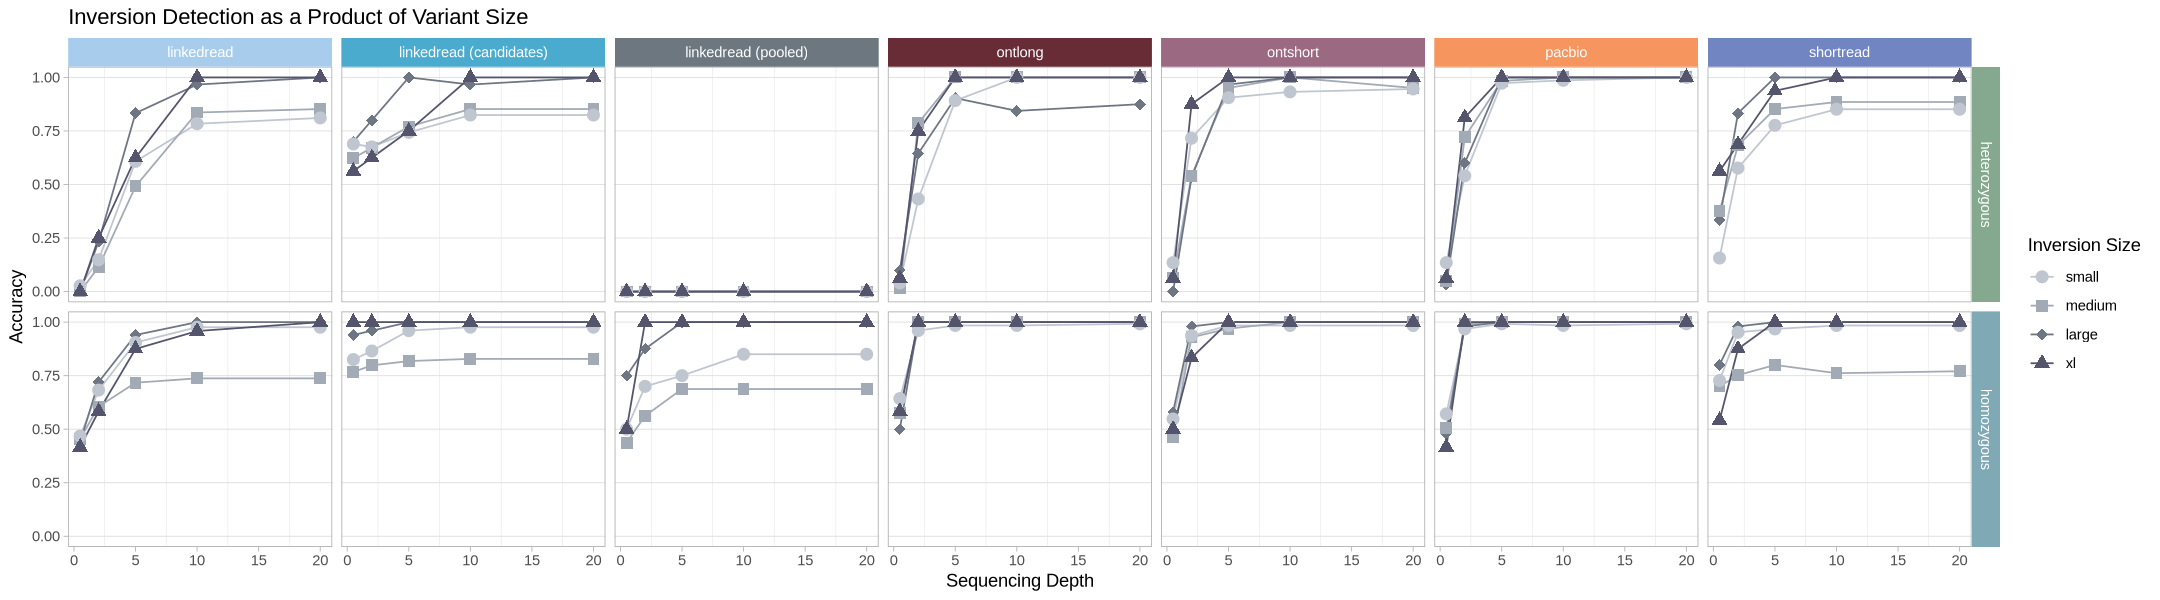

In [14]:
options(repr.plot.width = 18, repr.plot.height = 5)
.strip <- strip_themed(background_y = elem_list_rect(fill = zygosity_colors), background_x = elem_list_rect(fill = tech_colors))

filter(metrics) %>%
ggplot(aes(x = depth, y = Accuracy, color = size, group = size, shape = size)) +
    geom_line() +
    geom_point(size = 3) +
    scale_shape_manual(values = c(19,15,18,17)) +
    scale_color_manual(values = size_colors) +
    theme_light() +
    labs(title = "Inversion Detection as a Product of Variant Size", color = "Inversion Size", shape = "Inversion Size") +
    ylab("Accuracy") +
    xlab("Sequencing Depth") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid2(rows = vars(zygosity), cols = vars(technology), strip = .strip)

#### Holistic comparison of technologies
What does it look like when we compare the performance of hom/het within and across technologies for each inversion class?

How does this look with false positives?

Let's make it less busy by summing homozygous and heterozygous so it's a total assessment agnostic of zygotic state.

In [15]:
# Source - https://stackoverflow.com/a/18509816
# Posted by alko989, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-31, License - CC BY-SA 4.0

titlecase <- function(x) {
  substr(x, 1, 1) <- toupper(substr(x, 1, 1))
  x
}


In [16]:
plot_param <- function(param){
    paramname <- titlecase(param)
    .strip <- strip_themed(background_x = elem_list_rect(fill = zygosity_colors))
    param_zyg <- metrics_summary %>% filter(technology != "linkedread (pooled)") %>%
        ggplot(aes(x = depth, y = .data[[param]], color = technology, fill = technology, shape = technology, group = technology)) +
        geom_line() +
        geom_point(size = 6) +
        theme_light() +
        scale_shape_manual(name = "Technology", values = technology_shapes) +
        scale_color_manual(name = "Technology", values = tech_colors) +
        scale_fill_manual(name = "Technology", values = tech_colors) +
        scale_y_continuous(limits = c(0,1))+
        xlab("Sequencing Depth") +
        ylab(titlecase(param)) +
        labs(title = paste("Inversion Detection", paramname, "across technologies")) #+
        #facet_grid2(cols = vars(zygosity), strip = .strip)

    .strip <- strip_themed(background_y = elem_list_rect(fill = zygosity_colors), background_x = elem_list_rect(fill = size_colors))
    param_size <- metrics %>% filter(technology != "linkedread (pooled)") %>%
    ggplot(aes(x = depth, y = .data[[param]], color = technology, fill = technology, group = technology)) +
        geom_line(aes(linetype = technology)) +
        geom_point(size = 3, aes(shape = technology)) +
        theme_light() +
        scale_color_manual(values = tech_colors) +
        scale_fill_manual(values = tech_colors) +
        scale_linetype_manual(values = technology_lines) +
        scale_shape_manual(values = technology_shapes) +
        labs(linetype = "Technology", color = "Technology", fill = "Technology", shape = "Technology") +
        ylab(titlecase(param)) +
        xlab("Sequencing Depth") +
        theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
        facet_grid2(rows = vars(zygosity), cols = vars(size), strip = .strip)

    .strip <- strip_themed(background_y = elem_list_rect(fill = zygosity_colors), background_x = elem_list_rect(fill = depth_colors))
    param_depth <- metrics %>% filter(technology != "linkedread (pooled)") %>%
    ggplot(aes(x = size, y = .data[[param]], color = technology, fill = technology, group = technology)) +
        geom_line(aes(linetype = technology)) +
        geom_point(size = 3, aes(shape = technology)) +
        theme_light() +
        scale_color_manual(values = tech_colors) +
        scale_fill_manual(values = tech_colors) +
        scale_linetype_manual(values = technology_lines) +
        scale_shape_manual(values = technology_shapes) +
        labs(linetype = "Technology", color = "Technology", fill = "Technology", shape = "Technology") +
        ylab(titlecase(param)) +
        xlab("Variant Size") +
        theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
        facet_grid2(rows = vars(zygosity), cols = vars(depth), strip = .strip)

    param_by <- ggarrange(
        param_depth,
        param_size,
        ncol = 1, nrow = 2,
        heights = c(1, 1),
        labels = c('B', 'C'),
        label_size = 12,
        common.legend = TRUE,
        legend = "none"
    )

    paramplots <- ggarrange(
        param_zyg,
        param_by[[1]],
        ncol = 2,
        nrow = 1,
        #heights = c(1.4, 1),
        labels = c('A', ''),
        label_size = 12,
        common.legend = TRUE,
        legend = "bottom"
    )

    paramplots[[1]]
}

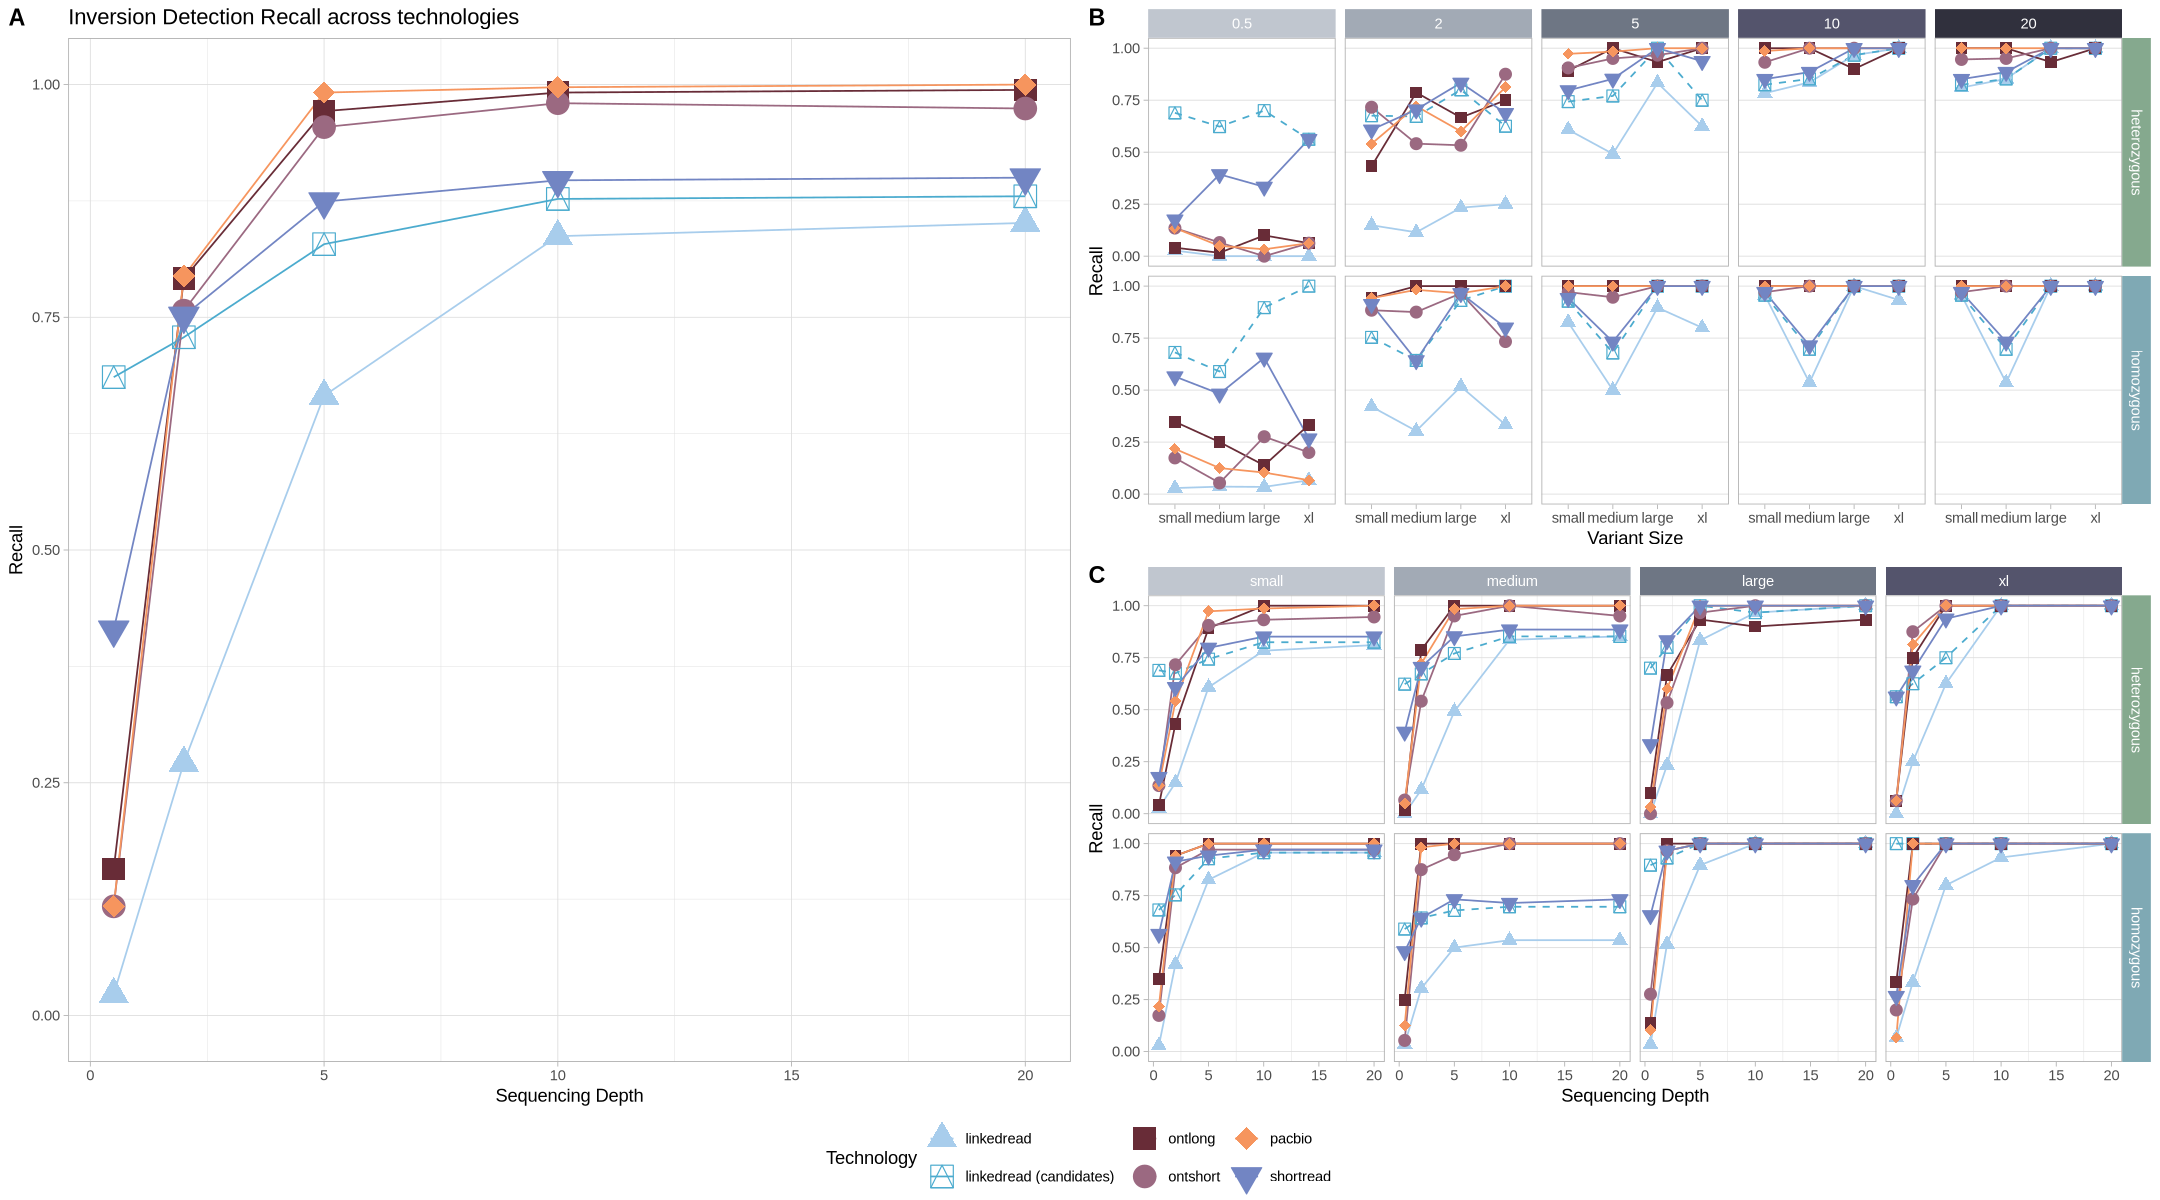

In [17]:
options(repr.plot.width = 18, repr.plot.height = 10)

plot_param("recall")

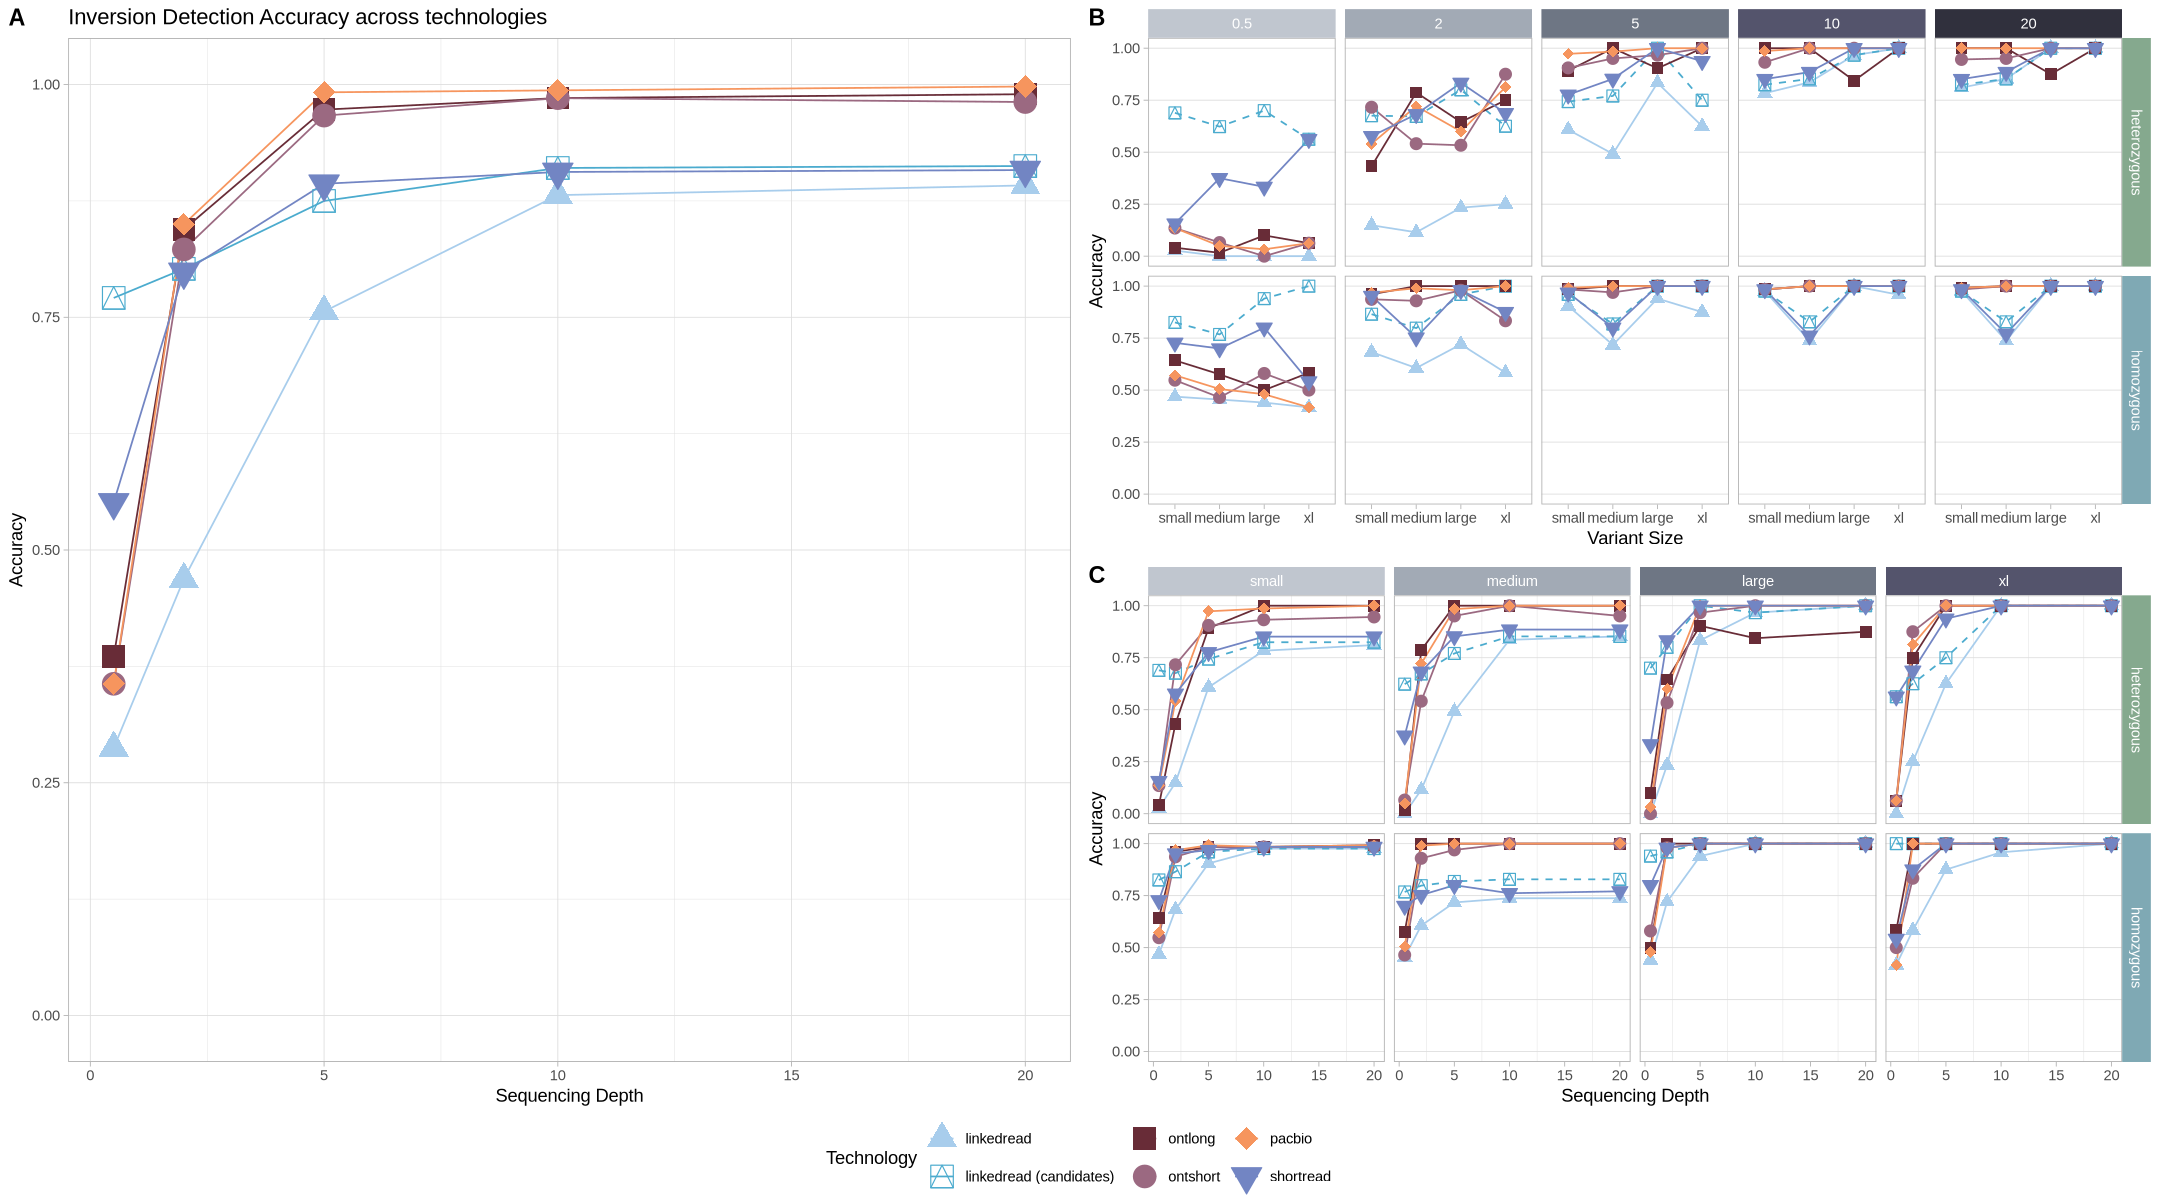

In [18]:
options(repr.plot.width = 18, repr.plot.height = 10)

plot_param("Accuracy")

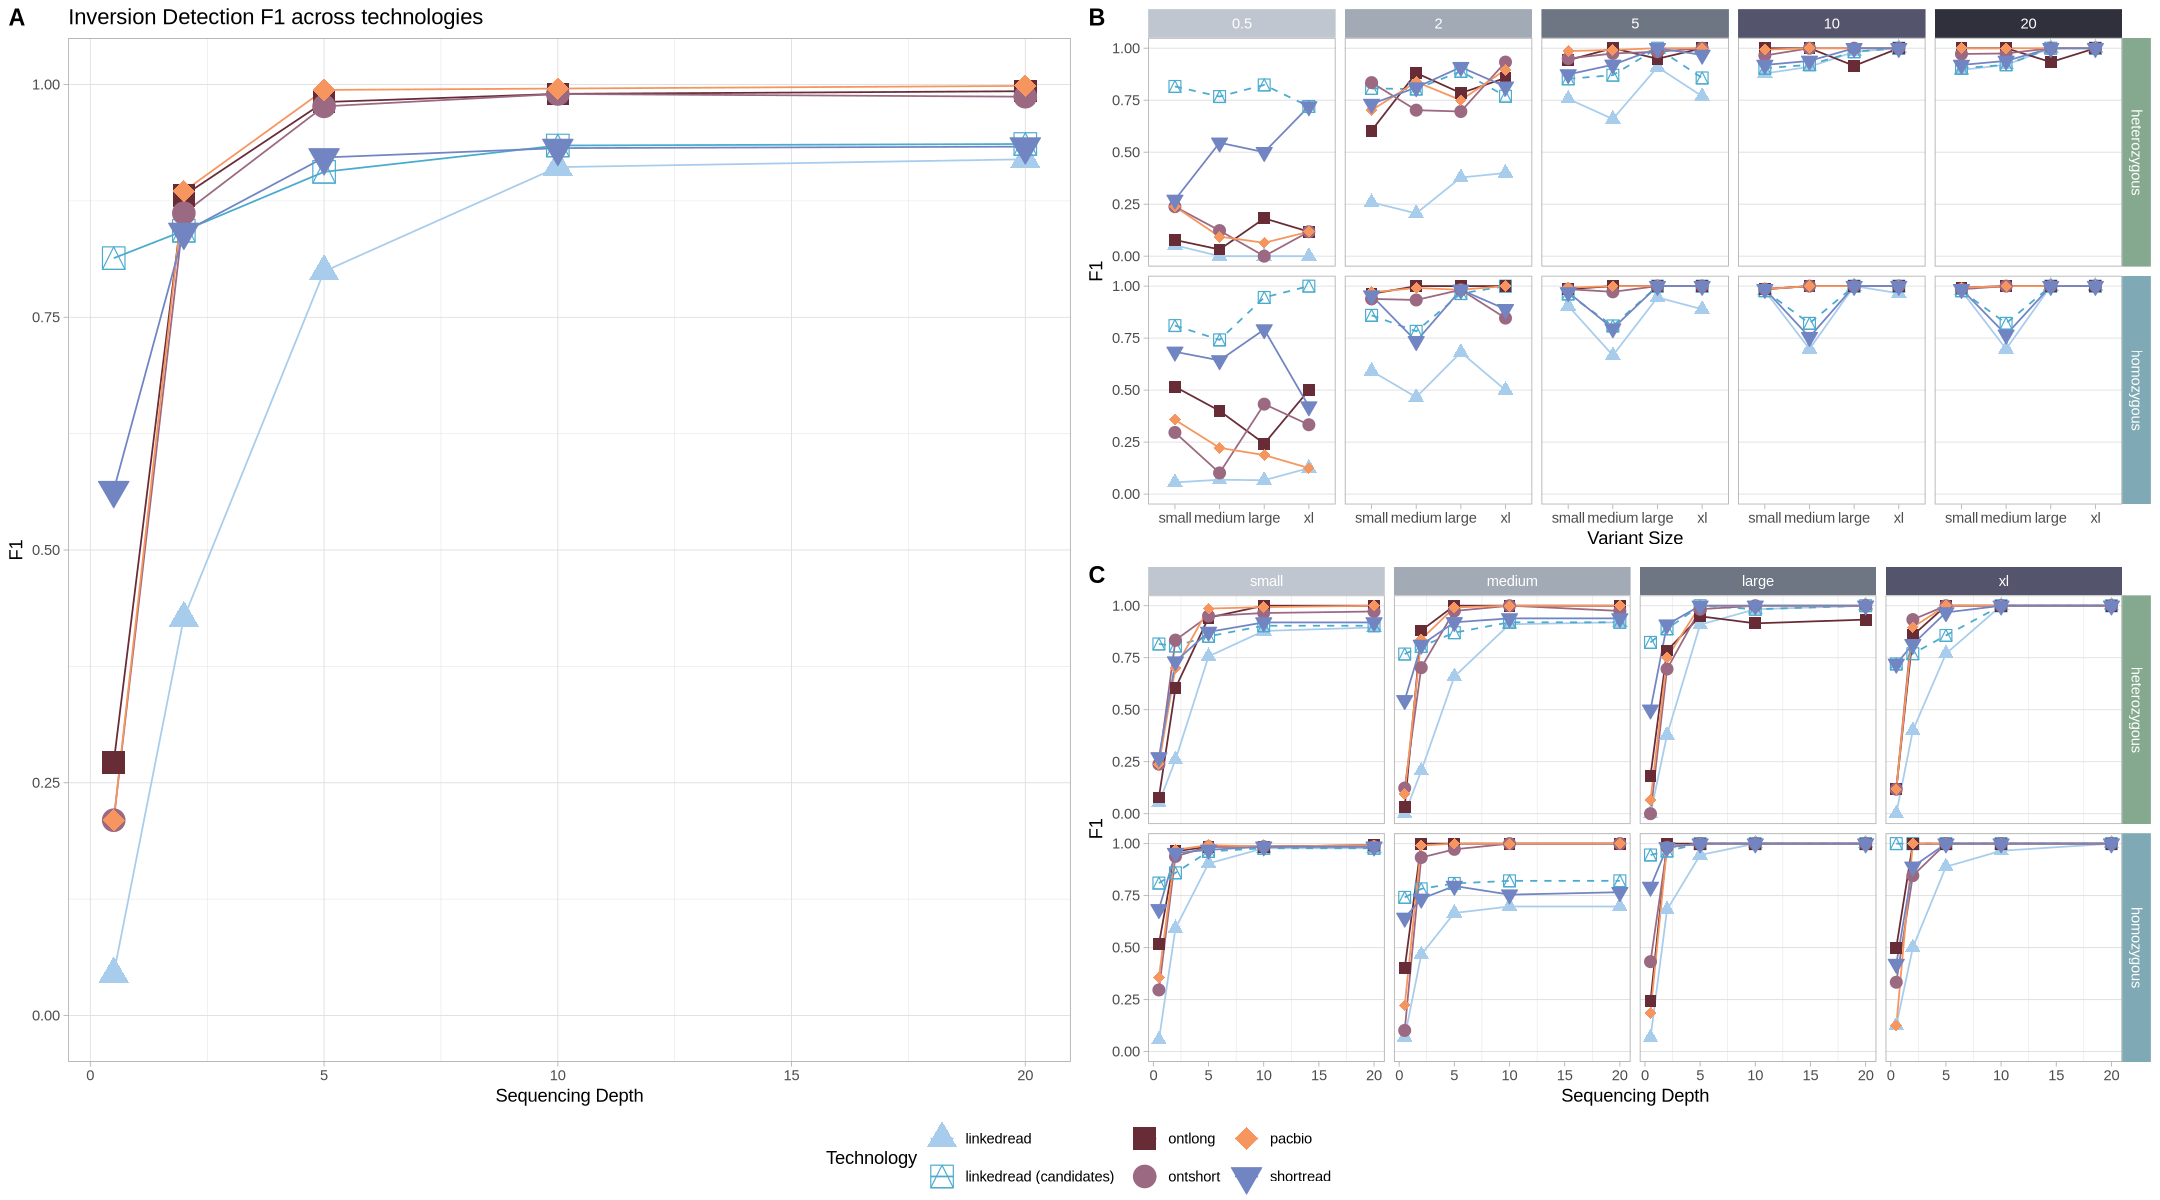

In [19]:
options(repr.plot.width = 18, repr.plot.height = 10)

plot_param("F1")

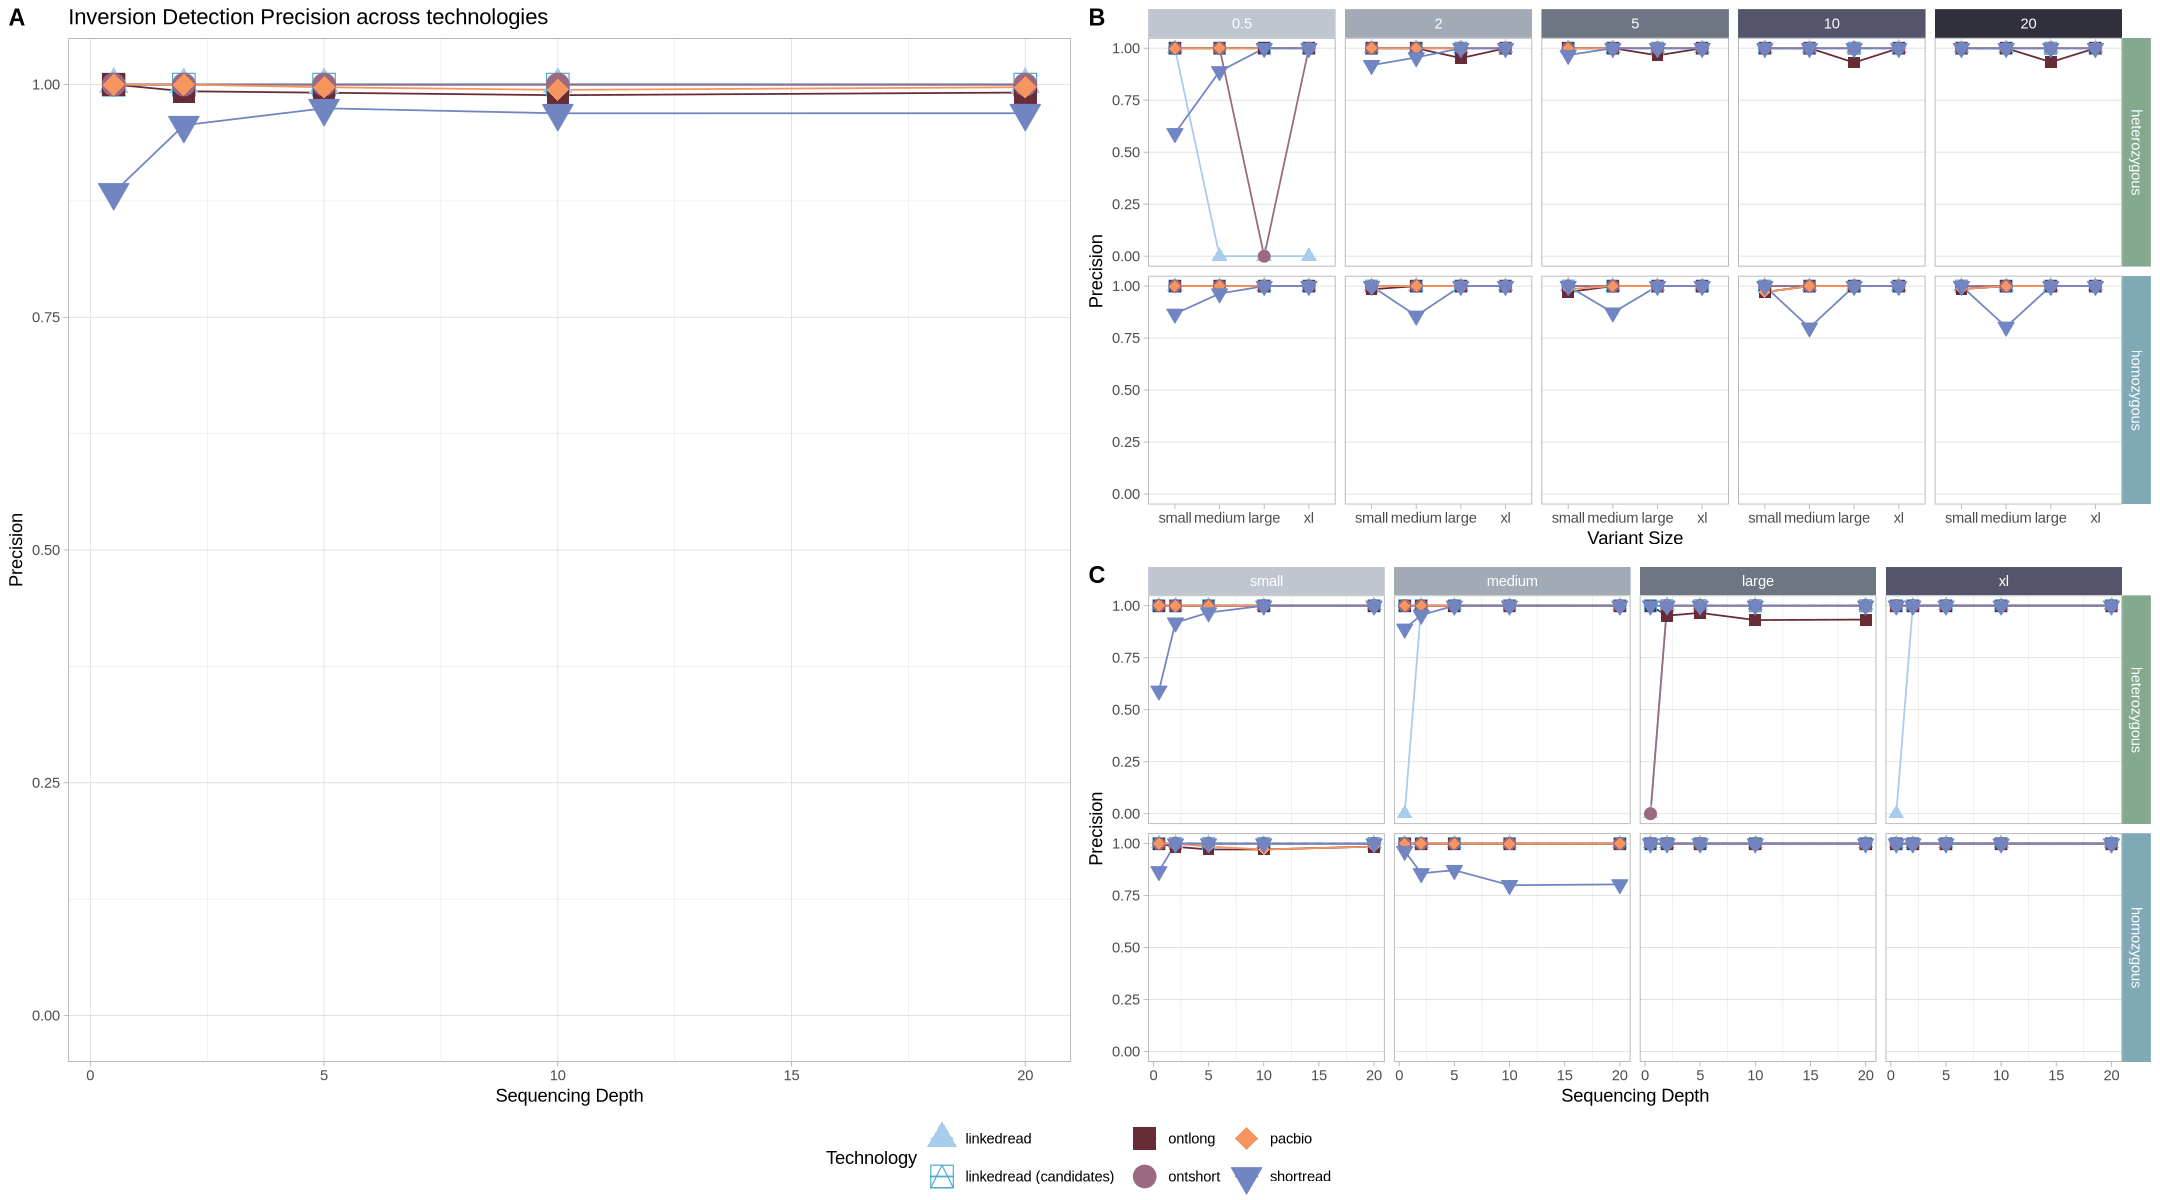

In [20]:
options(repr.plot.width = 18, repr.plot.height = 10)

plot_param("precision")

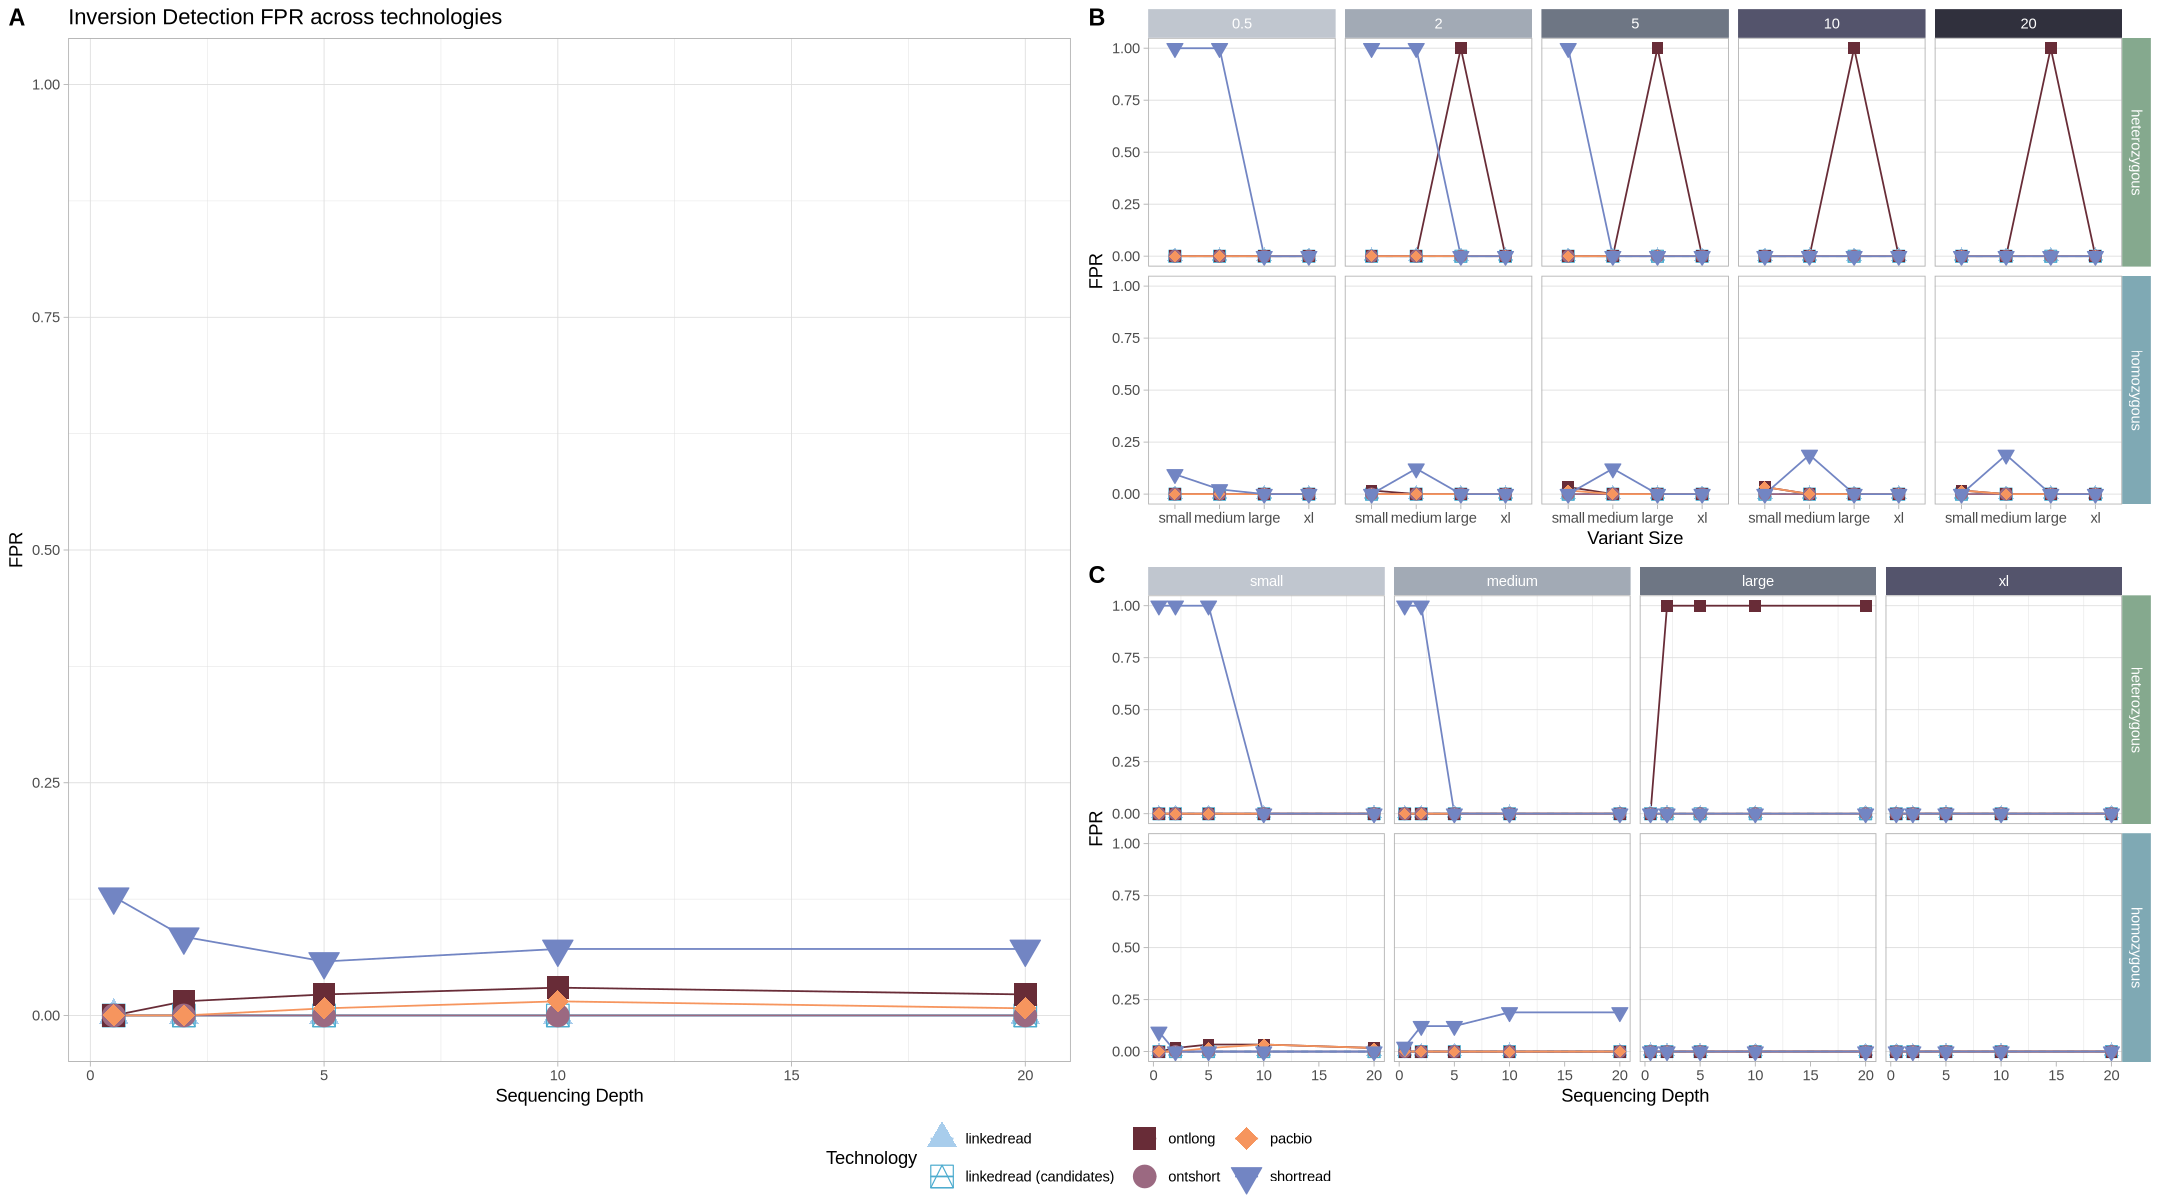

In [21]:
options(repr.plot.width = 18, repr.plot.height = 10)

plot_param("FPR")

### Pooled vs

In [31]:
poolmetrics <- arrange(samples_freq, size, depth, technology, assessment) %>%
    complete(size, depth, technology, frequency, assessment = .assess, fill = list(count = 0)) %>%
    pivot_wider(names_from = assessment, values_from = count) %>%
    rename(FN = "false negative", FP = "false positive", TN = "true negative", TP = "true positive")


unpooled <- poolmetrics %>% filter(technology %in% c("linkedread", "linkedread (candidates)", "pacbio")) %>%
    group_by(size, depth, technology) %>%
    summarize(FN = sum(FN), FP = sum(FP), TN = sum(TN), TP = sum(TP))

pooled <- poolmetrics %>% filter(technology == "linkedread (pooled)") %>%
    mutate(technology = paste0("pooled (", frequency, ")")) %>%
    select(-frequency)

poolplotdf <- rbind(unpooled, pooled) %>%
    mutate(
        technology = gsub("linkedread \\(candidates\\)", "candidates", technology),
        technology = gsub("linkedread", "single-sample", technology)
    )

head(poolplotdf)

`summarise()` has grouped output by 'size', 'depth'. You can override using the
`.groups` argument.


size,depth,technology,FN,FP,TN,TP
<ord>,<dbl>,<chr>,<int>,<int>,<int>,<int>
small,0.5,single-sample,139,0,57,4
small,0.5,candidates,45,0,57,98
small,0.5,pacbio,118,0,57,25
small,2.0,single-sample,103,0,57,40
small,2.0,candidates,41,0,57,102
small,2.0,pacbio,38,0,57,105


In [32]:
pool_overall <- poolplotdf %>% group_by(depth, technology) %>%
    summarize(FN = sum(FN), FP = sum(FP), TN = sum(TN), TP = sum(TP)) %>%
    mutate(
        precision = TP / (TP + FP),
        recall = TP / (TP + FN),
        F1 = 2 * ((precision * recall) / (precision + recall)),
        Accuracy = (TP + TN) / (TP + TN + FN + FP),
        FPR = FP / (FP + TN),
    )
head(pool_overall)

`summarise()` has grouped output by 'depth'. You can override using the
`.groups` argument.


depth,technology,FN,FP,TN,TP,precision,recall,F1,Accuracy,FPR
<dbl>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.5,candidates,110,0,130,240,1,0.68571429,0.81355932,0.7708333,0
0.5,pacbio,309,0,130,41,1,0.11714286,0.20971867,0.3562500,0
0.5,pooled (common),13,0,0,23,1,0.63888889,0.77966102,0.6388889,NaN
0.5,pooled (rare),10,0,0,2,1,0.16666667,0.28571429,0.1666667,NaN
0.5,single-sample,342,0,130,8,1,0.02285714,0.04469274,0.2875000,0
2.0,candidates,95,0,130,255,1,0.72857143,0.84297521,0.8020833,0


In [33]:
poolplotdf$edepth <- poolplotdf$depth 
poolplotdf$edepth[grepl("pooled", poolplotdf$technology)] <- poolplotdf$depth[grepl("pooled", poolplotdf$technology)] * 10
poolplotdf <- mutate(poolplotdf,
    precision = TP / (TP + FP),
    recall = TP / (TP + FN),
    F1 = 2 * ((precision * recall) / (precision + recall)),
    Accuracy = (TP + TN) / (TP + TN + FN + FP),
    FPR = FP / (FP + TN),
    size = factor(size, ordered = T, levels = c("small", "medium", "large", "xl"))
)

poolplotdf[is.na(poolplotdf)] <- 0

head(poolplotdf)

size,depth,technology,FN,FP,TN,TP,edepth,precision,recall,F1,Accuracy,FPR
<ord>,<dbl>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
small,0.5,single-sample,139,0,57,4,0.5,1,0.02797203,0.05442177,0.305,0
small,0.5,candidates,45,0,57,98,0.5,1,0.68531469,0.81327801,0.775,0
small,0.5,pacbio,118,0,57,25,0.5,1,0.17482517,0.29761905,0.410,0
small,2.0,single-sample,103,0,57,40,2.0,1,0.27972028,0.43715847,0.485,0
small,2.0,candidates,41,0,57,102,2.0,1,0.71328671,0.83265306,0.795,0
small,2.0,pacbio,38,0,57,105,2.0,1,0.73426573,0.84677419,0.810,0


In [44]:
lr_shapes <- c(
    "single-sample" = 17,
    "pooled (rare)" = 5,
    "pooled (common)" = 8,
    "pacbio" = 11,
    "candidates" = 1
)

lr_colors <- c(
    "single-sample" = "#a8cdec",
    "pooled (rare)" = "#bb5b83",
    "pooled (common)" = "#4C4271",
    "pacbio" = "#3aaa5a",
    "candidates" = "#ef8342"
)

F1 with depth facets

In [40]:
.strip <- strip_themed(background_x = elem_list_rect(fill = depth_colors))
pool_size_strip <- poolplotdf %>%
    ggplot(aes(x = size, y = F1, color = technology, fill = technology, shape = technology, group = technology)) +
    geom_line() +
    geom_point(size = 6) +
    theme_light() +
    scale_shape_manual(name = "Technology", values = lr_shapes) +
    scale_color_manual(name = "Technology", values = lr_colors) +
    scale_fill_manual(name = "Technology", values = lr_colors) +
    scale_y_continuous(limits = c(0,1))+
    xlab("Inversion Size") +
    ylab(titlecase("F1")) +
    facet_grid2(cols = vars(depth), strip = .strip)


Accuracy with depth-facets

In [41]:
.strip <- strip_themed(background_x = elem_list_rect(fill = depth_colors))
pool_size_strip_acc <- poolplotdf %>%
    ggplot(aes(x = size, y = Accuracy, color = technology, fill = technology, shape = technology, group = technology)) +
    geom_line() +
    geom_point(size = 6) +
    theme_light() +
    scale_shape_manual(name = "Technology", values = lr_shapes) +
    scale_color_manual(name = "Technology", values = lr_colors) +
    scale_fill_manual(name = "Technology", values = lr_colors) +
    scale_y_continuous(limits = c(0,1))+
    xlab("Inversion Size") +
    ylab(titlecase("Accuracy")) +
    facet_grid2(cols = vars(depth), strip = .strip)

Overall

In [42]:
pool_overall_plot <- pool_overall %>%
    ggplot(aes(x = depth, y = F1, color = technology, fill = technology, shape = technology, group = technology)) +
    geom_line() +
    geom_point(size = 6) +
    theme_light() +
    scale_shape_manual(name = "Technology", values = lr_shapes) +
    scale_color_manual(name = "Technology", values = lr_colors) +
    scale_fill_manual(name = "Technology", values = lr_colors) +
    scale_y_continuous(limits = c(0,1))+
    xlab("Per-Sample Sequencing Depth") +
    ylab(titlecase("F1 Score")) +
    labs(title = "Comparison of linked-read inversion calling strategies")


Overall with effective depth

In [48]:
pool_overall_effdepth_plot <- pool_overall %>%
    mutate(effective_depth = if_else(str_detect(technology, "pooled"), depth * 10, depth)) %>%
    ggplot(aes(x = effective_depth, y = F1, color = technology, fill = technology, shape = technology, group = technology)) +
    geom_line() +
    geom_point(size = 6) +
    theme_light() +
    scale_shape_manual(name = "Technology", values = lr_shapes) +
    scale_color_manual(name = "Technology", values = lr_colors) +
    scale_fill_manual(name = "Technology", values = lr_colors) +
    scale_y_continuous(limits = c(0,1))+
    xlab("Effective Sequencing Depth") +
    ylab(titlecase("F1 Score")) +
    labs(title = "Comparison of linked-read inversion calling strategies")


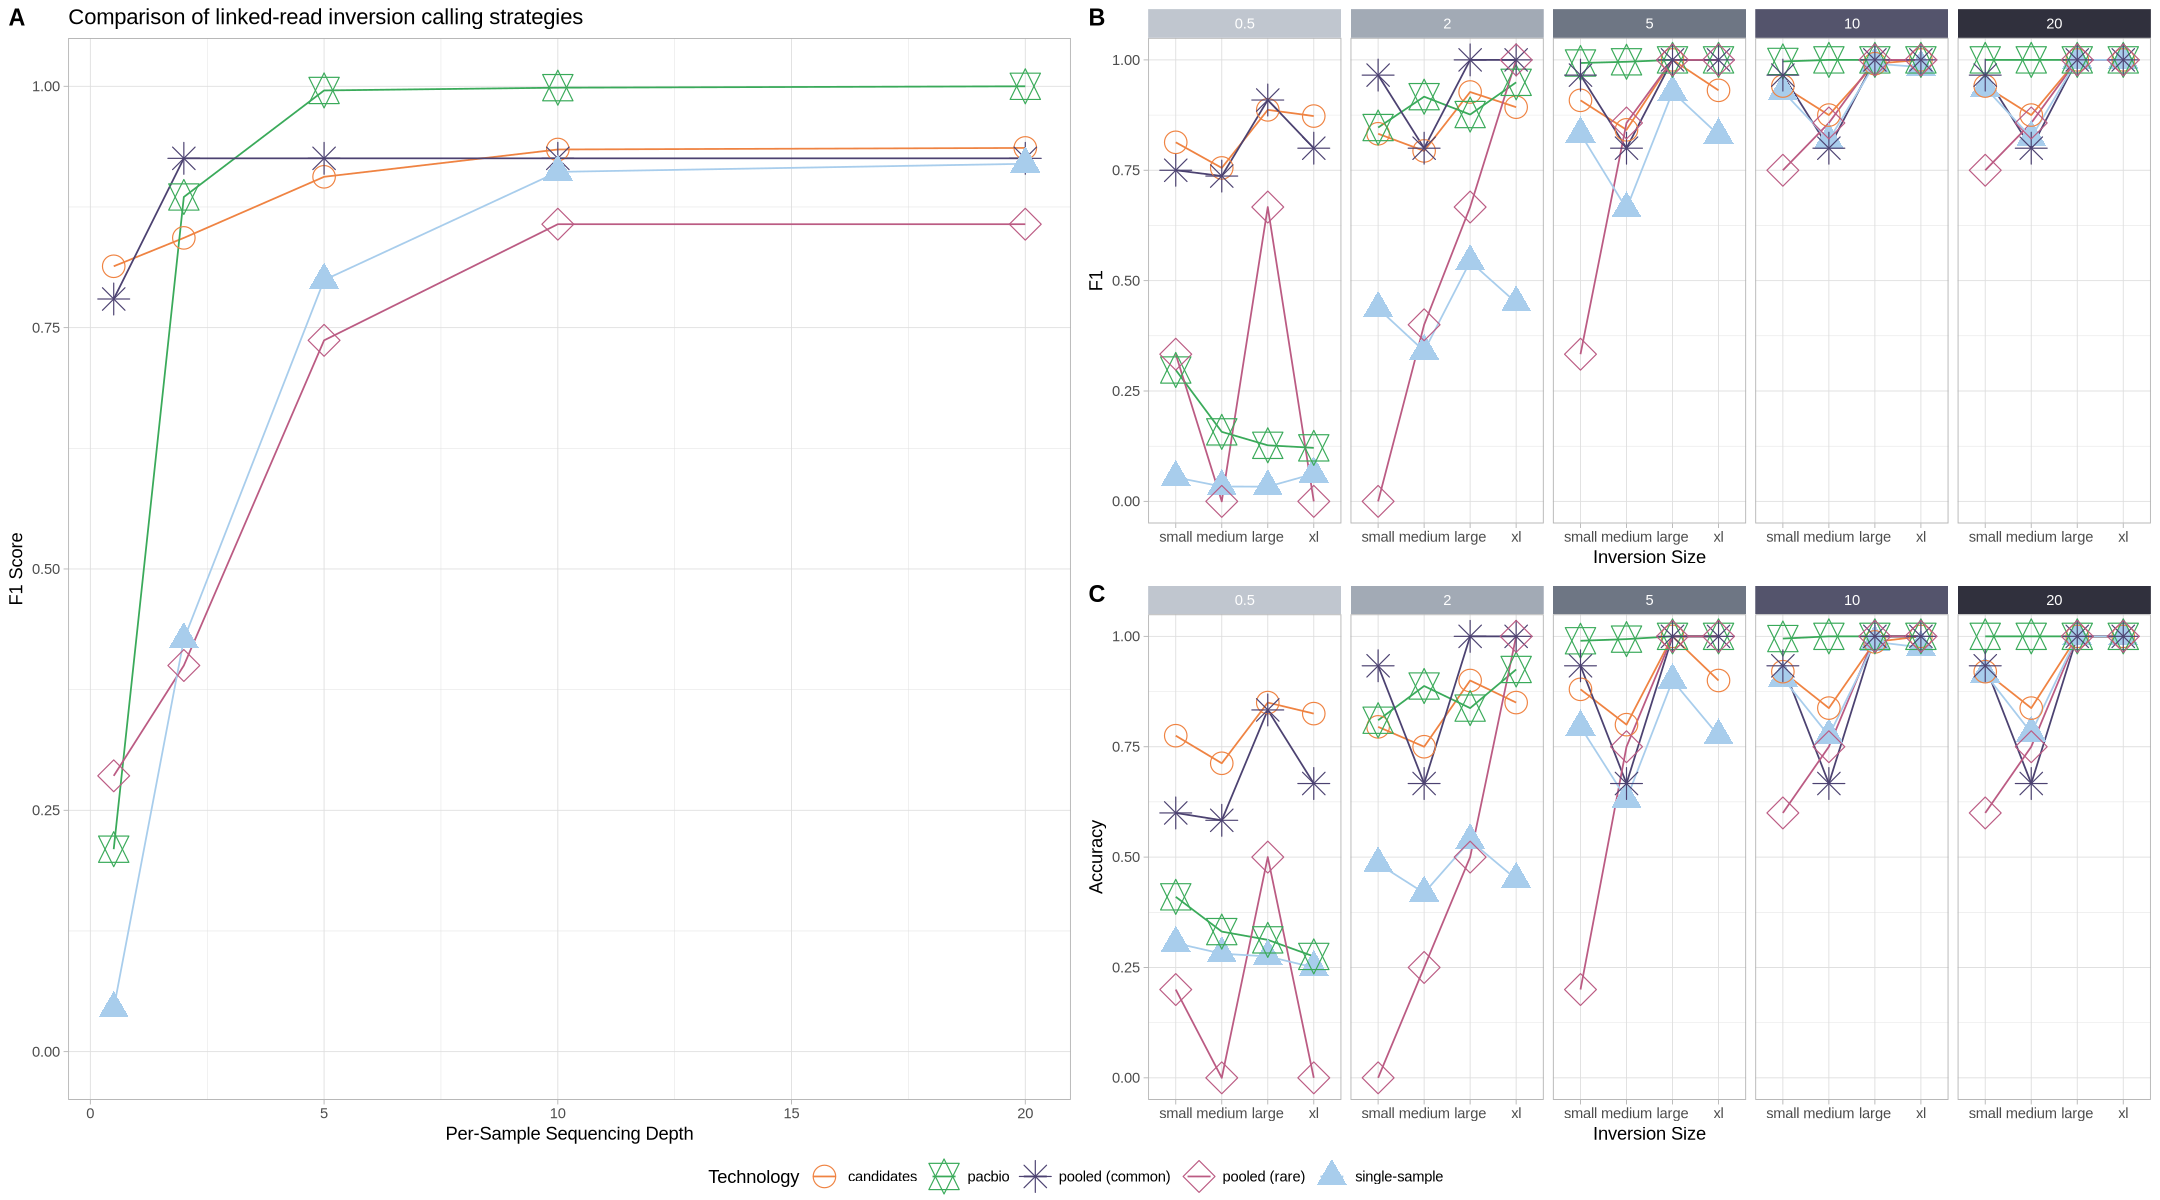

In [ ]:
param_by <- ggarrange(
    pool_size_strip,
    pool_size_strip_acc,
    ncol = 1, nrow = 2,
    heights = c(1, 1),
    labels = c('B', 'C'),
    label_size = 12,
    common.legend = TRUE,
    legend = "none"
)

paramplots <- ggarrange(
    pool_overall_plot,
    param_by[[1]],
    ncol = 2,
    nrow = 1,
    #heights = c(1.4, 1),
    labels = c('A', ''),
    label_size = 12,
    common.legend = TRUE,
    legend = "bottom"
)

paramplots[[1]]
#pool_overall_effdepth_plot

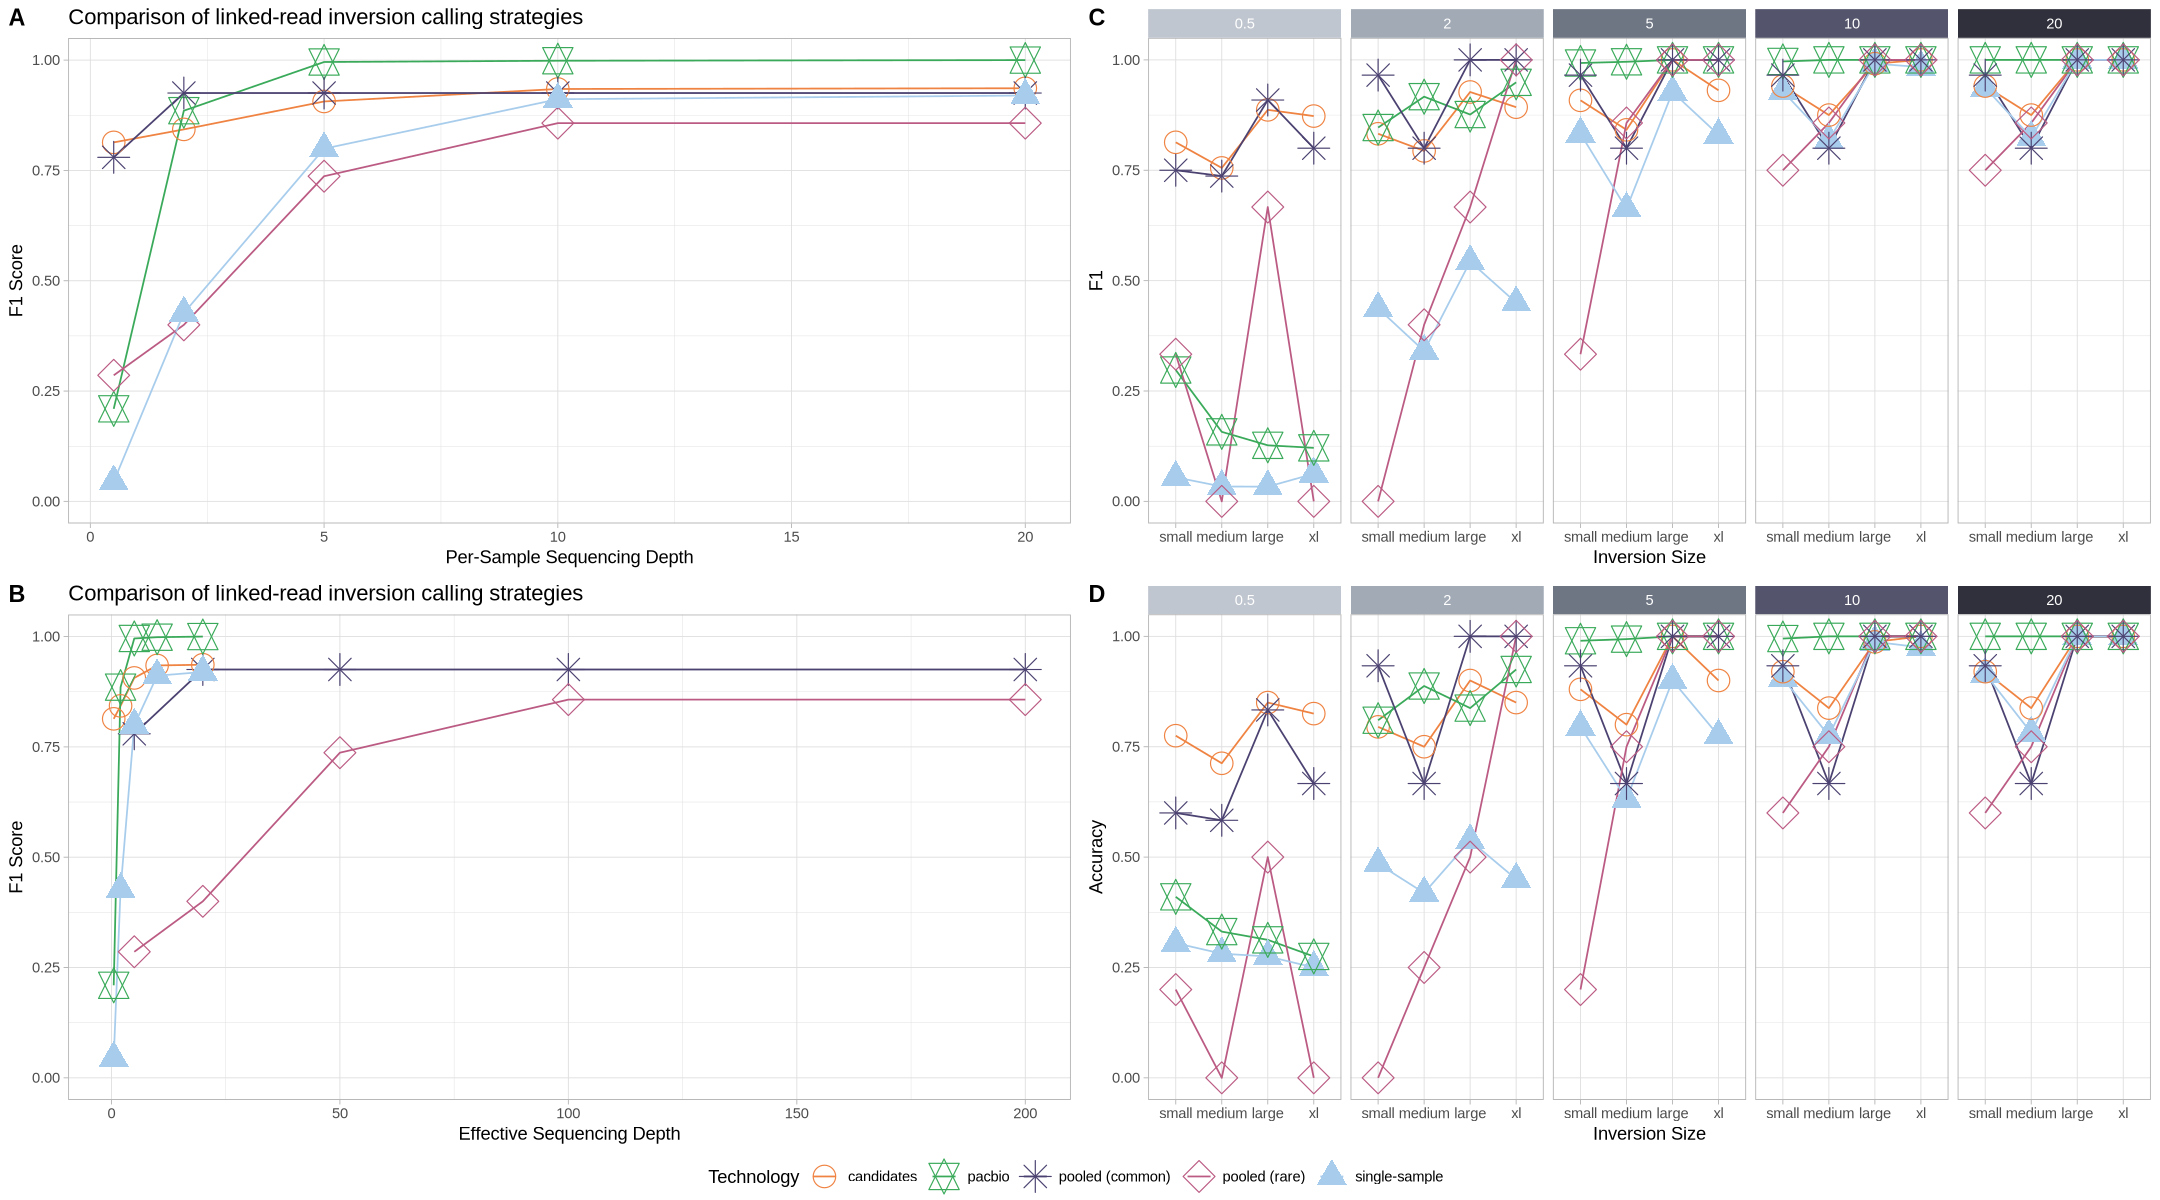

In [51]:
param_by <- ggarrange(
    pool_overall_plot,
    pool_size_strip,
    pool_overall_effdepth_plot, 
    pool_size_strip_acc,
    ncol = 2, nrow = 2,
    heights = c(1, 1),
    labels = c('A','C','B', 'D'),
    label_size = 12,
    common.legend = TRUE,
    legend = "bottom"
)

param_by[[1]]
#pool_overall_effdepth_plot